# Hydrostatic simulation on Arabidopsis root

Read RSML file and run a simulation of the sap flux from an Arabidopsis de-topped root plunged in a hydroponic solution at a hydrostatic pressure of 0.4 Mpa when its  base is at the atmospheric pressure.

In [1]:
import numpy as np

# Import 2D and 3D viewer with PlantGL
from openalea.plantgl.algo.view import view # 2D viewer
from openalea.widgets.plantgl import PlantGL # 3D viewer 

# Import HydroRoot modules
from openalea import hydroroot
from openalea.hydroroot import (
    main,
    hydro_io,
    radius,
    display,
)

## RSML to MTG
### 1. Read the rsml file *arabidopsis.rsml* and convert it to a MTG *g* of segments of 0.1 mm

In [2]:
g = hydroroot.hydro_io.read_rsml('arabidopsis.rsml', segment_length=1.0e-4)

### 2. Set the root radii
   The radius setting follows the Arabidopsis model describeded in Boursiac et al. 2022. The root radius is set according to the radius of the primary root $r_{ref}$ and the order of the lateral as follows: $r_{lat} = \beta^{order} r_{ref}$. $\beta$ is the radius decreasing facteur between root orders.

In [3]:
# primary root radius 7.0e-5 m, beta = 0.7
g = hydroroot.radius.ordered_radius(g, 
                                    ref_radius=7.0e-5, 
                                    order_decrease_factor=0.7)

# Compute the position of each segment relative to the axis bearing it
g = hydroroot.radius.compute_relative_position(g) 

In [11]:
# radial conductivity profile: distance to tip (m) vs kr (10-9 m.s-1.MPa-1)
kx=np.array([0.0, 0.2]) # distance to tip
ky=np.array([30, 30]) # kr
k_radial_data=(kx,ky)

# axial conductance profile: distance to tip (m) vs Kx (10-9 m4.s-1.MPa-1)
Kx=np.array([0.0, 0.2]) # distance to tip
Ky=np.array([3.0e-7,4.0e-4]) # Kx
K_axial_data=(Kx,Ky)

## Flux and equivalent conductance calculation

for a detopped root in a hydroponic medium at 0.4 MPa, its base at 0.1 MPa.

In [12]:
g, keq, jv = hydroroot.main.hydroroot_flow(g, psi_e = 0.4, psi_base = 0.1,
                            axial_conductivity_data = K_axial_data, 
                            radial_conductivity_data = k_radial_data)

Print results

In [13]:
print(f'equivalent root conductance (10-9 m3/s/MPa): {keq:.2e} sap flux (microL/s): {jv:.2e}')

equivalent root conductance (10-9 m3/s/MPa): 1.21e-02 sap flux (microL/s): 3.62e-03


## Plots

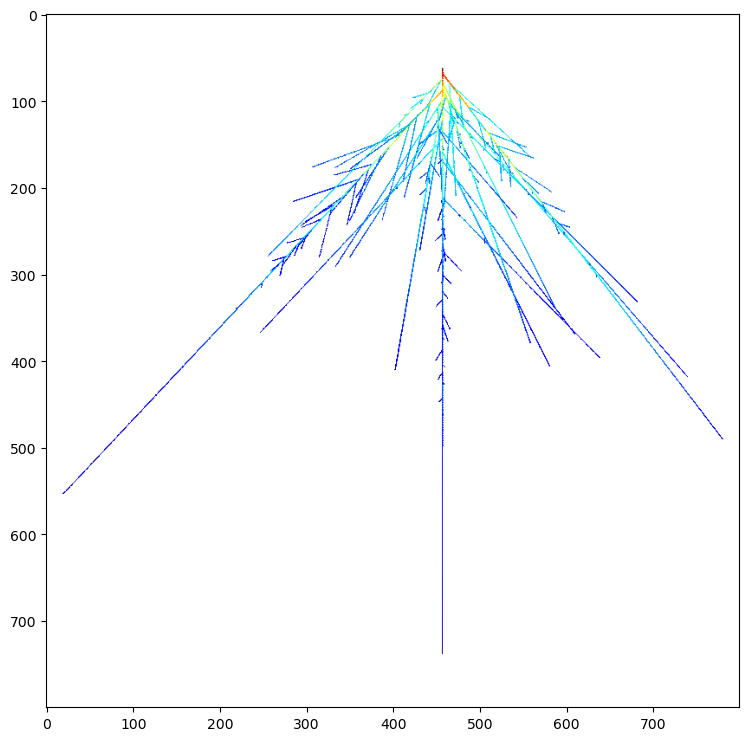

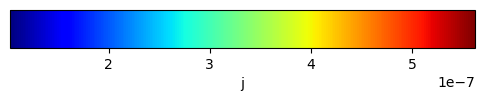

In [14]:
s = hydroroot.display.mtg_scene(g, prop_cmap = 'j') # create a scene from the mtg with the property j is the radial flux in ul/s
# PlantGL(s) # display the root into the plantgl oawidget
view(s) # view in 2D
hydroroot.display.property_scale_bar(g, 'j')

## Changing radial conductivity
You may change the radial conductivity, for instance increasing it by 10, and see the impact on the water uptake

equivalent root conductance (10-9 m3/s/MPa): 3.54e-02 sap flux (microL/s): 1.06e-02


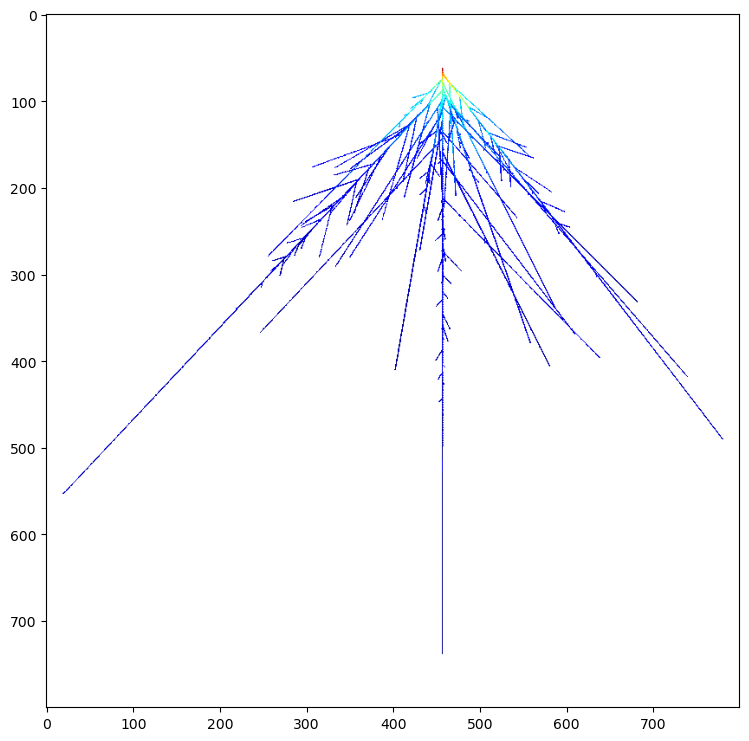

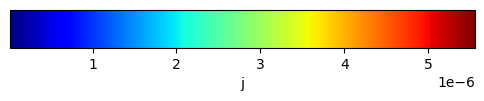

In [16]:
k_radial_data=(kx,10.0*ky)
g, keq, jv = hydroroot.main.hydroroot_flow(g, psi_e = 0.4, psi_base = 0.1, axial_conductivity_data = K_axial_data, radial_conductivity_data = k_radial_data)
print(f'equivalent root conductance (10-9 m3/s/MPa): {keq:.2e} sap flux (microL/s): {jv:.2e}')
s = hydroroot.display.mtg_scene(g, prop_cmap='j')
view(s) # to reduce notebook size we use here a 2D view but use PlantGL(s) to 3D
hydroroot.display.property_scale_bar(g, 'j')

## Changing axial conductance

We can observe the impact by increasing only the axial conductance for example by a factor 10 4.

equivalent root conductance (10-9 m3/s/MPa): 1.76e-02 sap flux (microL/s): 5.27e-03


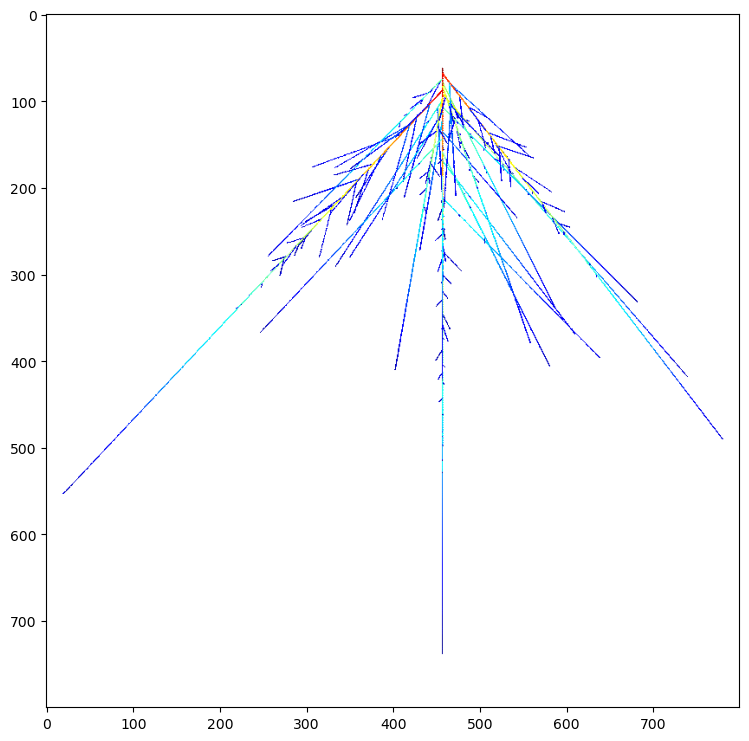

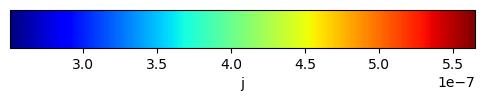

In [18]:
k_radial_data=(kx,ky)
K_axial_data=(Kx,Ky*10.0)
g, keq, jv = hydroroot.main.hydroroot_flow(g, psi_e = 0.4, psi_base = 0.1, axial_conductivity_data = K_axial_data, radial_conductivity_data = k_radial_data)
print(f'equivalent root conductance (10-9 m3/s/MPa): {keq:.2e} sap flux (microL/s): {jv:.2e}')
s = hydroroot.display.mtg_scene(g, prop_cmap='j')
view(s) # to reduce notebook size we use here a 2D view but use PlantGL(s) to 3D
hydroroot.display.property_scale_bar(g, 'j')